In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import os
import json
import re
from utils import load_json
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
def importance_to_binary_label(importance):
    importance = int(importance)
    if importance == 1:
        return 1
    else:
        return 0

def category_to_binary_label(category):
    if category == "KEY CASE":
        #print('1 == ', category)
        return 1
    else:
        #print('0 == ', category)
        return 0

def get_df(output_dir = './results_openai/'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        #print(result)
        result_data = load_json(os.path.join(output_dir, result))
        item_id = result.split("_")[-1].split(".")[0]
        #if int(result_data["importance"]) == 1:
        #    print(result_data["importance"], result_data["cot_facts"]['classification'])
        cot_facts_classification = category_to_binary_label(result_data["cot_facts"]['classification'])
        cot_law_classification = category_to_binary_label(result_data["cot_law"]['classification'])
        cot_facts_law_classification = category_to_binary_label(result_data["cot_facts_law"]['classification'])
        importance = int(result_data["importance"])
        ground_truth = importance_to_binary_label(importance)

        data.append(
            {
                "item_id": item_id,
                "facts": cot_facts_classification,
                "law": cot_law_classification,
                "facts_law": cot_facts_law_classification,
                "ground_truth": ground_truth,
                "importance": importance
            }
        )

    df = pd.DataFrame(data)
    return df


In [5]:
def get_metrics_binary(df, column):
    # Key Case vs. All
    # Ground truth: 1 for key case, 0 for not key case
    y_true = df['ground_truth']
    # Model predictions: 1 for key case, 0 for not key case
    y_pred = df[column]

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="binary")
    recall = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")

    # Classification report for additional insights
    rreport = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"], output_dict=True)
    report = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"])

    # Extracting micro and macro F1 scores
    micro_f1 = rreport["accuracy"]  # Micro F1 is equivalent to accuracy in binary classification
    macro_f1 = rreport["macro avg"]["f1-score"]

    # Presenting results
    metrics = {

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Micro F1": micro_f1,
        "Macro F1": macro_f1,
    }
    return metrics, report


In [6]:
def get_confusion_matrix(df, column):
    cm = confusion_matrix(df['ground_truth'], df[column], normalize="true")
    return cm

def plot_confusion_matrix(df, column):
    cm = get_confusion_matrix(df, column)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


In [7]:
df = get_df()

In [8]:
df.shape

(525, 6)

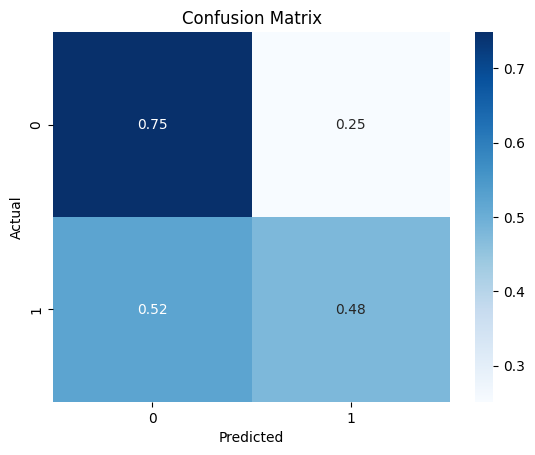

In [9]:
plot_confusion_matrix(df, "facts")
metrics, report = get_metrics_binary(df, "facts")

In [9]:
metrics

{'Accuracy': 0.6704761904761904,
 'Precision': 0.43373493975903615,
 'Recall': 0.4768211920529801,
 'F1 Score': 0.45425867507886436,
 'Micro F1': 0.6704761904761904,
 'Macro F1': 0.6091211520005508}

In [10]:
print(report)

              precision    recall  f1-score   support

Not Key Case       0.78      0.75      0.76       374
    Key Case       0.43      0.48      0.45       151

    accuracy                           0.67       525
   macro avg       0.61      0.61      0.61       525
weighted avg       0.68      0.67      0.67       525



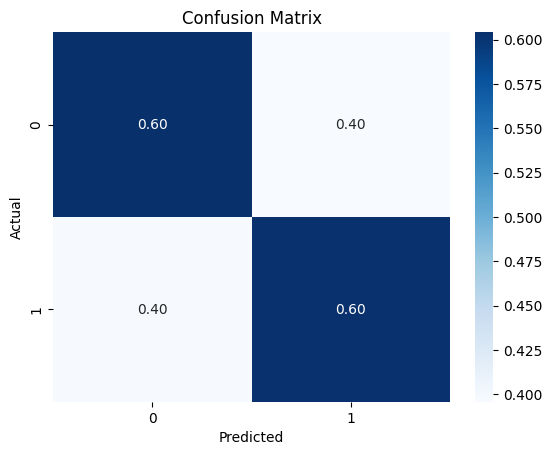

In [11]:
plot_confusion_matrix(df, "law")
metrics, report = get_metrics_binary(df, "law")

In [12]:
metrics

{'Accuracy': 0.6038095238095238,
 'Precision': 0.3807531380753138,
 'Recall': 0.6026490066225165,
 'F1 Score': 0.4666666666666667,
 'Micro F1': 0.6038095238095238,
 'Macro F1': 0.5757575757575757}

In [13]:
print(report)

              precision    recall  f1-score   support

Not Key Case       0.79      0.60      0.68       374
    Key Case       0.38      0.60      0.47       151

    accuracy                           0.60       525
   macro avg       0.59      0.60      0.58       525
weighted avg       0.67      0.60      0.62       525



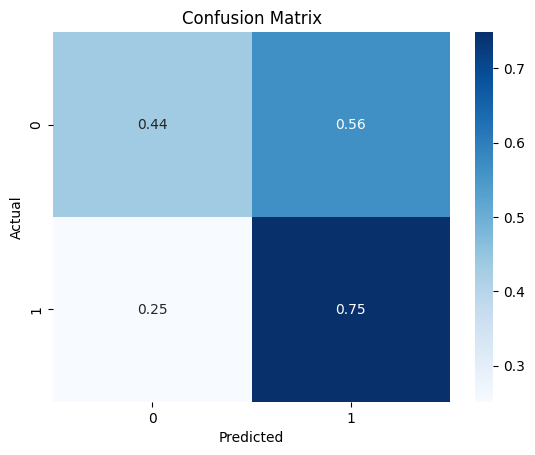

In [14]:
plot_confusion_matrix(df, "facts_law")
metrics, report = get_metrics_binary(df, "facts_law")

In [15]:
metrics

{'Accuracy': 0.5257142857142857,
 'Precision': 0.3487654320987654,
 'Recall': 0.7483443708609272,
 'F1 Score': 0.47578947368421054,
 'Micro F1': 0.5257142857142857,
 'Macro F1': 0.5213729977116706}

In [16]:
print(report)

              precision    recall  f1-score   support

Not Key Case       0.81      0.44      0.57       374
    Key Case       0.35      0.75      0.48       151

    accuracy                           0.53       525
   macro avg       0.58      0.59      0.52       525
weighted avg       0.68      0.53      0.54       525



In [10]:
def collect_reasonings(output_dir = './results_openai/'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        #print(result)
        result_data = load_json(os.path.join(output_dir, result))
        item_id = result.split("_")[-1].split(".")[0]
        if int(result_data["importance"]) != 1:
            continue
        cot_facts_classification = (result_data["cot_facts"]['reasoning'])
        cot_law_classification = (result_data["cot_law"]['reasoning'])
        cot_facts_law_classification = (result_data["cot_facts_law"]['reasoning'])
        importance = int(result_data["importance"])

        data.append(
            {
                "item_id": item_id,
                "facts": cot_facts_classification,
                "law": cot_law_classification,
                "facts_law": cot_facts_law_classification,
                "importance": importance
            }
        )

    df = pd.DataFrame(data)
    return df


In [11]:
df_reasons = collect_reasonings()   

In [13]:
df_reasons.to_csv('cot_binary_data_v2reasons.csv', index=False)

In [17]:
df[['facts', 'law', 'facts_law', 'ground_truth']].apply(pd.Series.value_counts)

,facts,law,facts_law,ground_truth
0,359,286,201,374
1,166,239,324,151


In [18]:
filtered_df = df.query('ground_truth == 1 and facts == 1 and law == 0 and facts_law == 0')
len(filtered_df)

11

In [19]:
filtered_df

,item_id,facts,law,facts_law,ground_truth,importance
23,001-183395,1,0,0,1,1
90,001-183947,1,0,0,1,1
112,001-172963,1,0,0,1,1
122,001-181789,1,0,0,1,1
123,001-175121,1,0,0,1,1
155,001-168066,1,0,0,1,1
179,001-182243,1,0,0,1,1
212,001-170359,1,0,0,1,1
231,001-188268,1,0,0,1,1
465,001-170388,1,0,0,1,1


In [20]:
filtered_df = df.query('ground_truth == 0 and facts == 0 and facts_law == 1')
len(filtered_df)

140

In [21]:
filtered_df['importance'].value_counts()

importance
3    82
4    46
2    12
Name: count, dtype: int64

In [22]:
filtered_df

,item_id,facts,law,facts_law,ground_truth,importance
4,001-215475,0,0,1,0,3
7,001-169214,0,1,1,0,3
12,001-219786,0,1,1,0,3
16,001-205165,0,0,1,0,4
18,001-164715,0,1,1,0,2
...,...,...,...,...,...,...
509,001-206149,0,1,1,0,3
512,001-209033,0,1,1,0,2
514,001-161528,0,1,1,0,3
517,001-187476,0,0,1,0,3


In [23]:
filtered_df = df.query('ground_truth == 1 and facts == 0 and facts_law == 1')
len(filtered_df)

52

In [24]:
filtered_df['importance'].value_counts()

importance
1    52
Name: count, dtype: int64

In [25]:
s = {
    "cot_facts": {
        "explanation": "To determine whether this case qualifies as a key case or not, I need to analyze the facts for their broader implications on ECHR jurisprudence. The cases described involve individual applicants encountering delays and the eventual time-barring of criminal investigations in San Marino. The applicants were victims seeking justice for various grievances, including fraud, personal injury, and defamation, but the investigations did not progress effectively, leading to the conclusion of time-barring without substantial developments in law or principles. \n\nThe issues presented primarily revolve around procedural shortcomings, including delays in investigations and the consequent time-barring of criminal charges. However, these procedural matters do not address or establish new legal principles or offer significant interpretations concerning human rights law that would affect broader jurisprudence. The cases align more closely with existing case law regarding the right to an effective remedy and the reasonable time requirement under Article 6 of the ECHR but do not modify or create either existing or new interpretations of the Convention.\n\nOverall, the implications of this case seem confined to its immediate circumstances without significant contributions to the understanding or application of human rights law.",
        "classification": "NOT KEY CASE",
        "reasoning": "The case applies existing case law regarding procedural delays and time limitations without establishing new legal principles or significant implications beyond the immediate dispute."
    },
    "cot_law": {
        "explanation": "In analyzing the provided case law section, it is evident that the case involves multiple applicants challenging the outcomes related to their civil claims due to procedural issues in the San Marino judicial system. The Court examined the applicability of Article 6(1) of the European Convention on Human Rights, which guarantees access to court, especially concerning the determination of civil rights and obligations. The applicants argued that the excessive delays in the investigation led to the inability to pursue their civil claims effectively. \n\nThe Court ultimately determined that there was a violation of Article 6(1) for several applicants due to the inactivity of the judicial authorities, which significantly affected their ability to have their civil rights determined. This case contributes to the understanding of the right to access to court in conjunction with domestic legal systems and clarifies the responsibilities of judicial authorities in ensuring that victims can pursue their claims effectively within the established framework. \n\nWhile the case conveys procedural application of existing principles, the emphasis on the inactivity of authorities leading to the time-bar and the applicability of civil claims may guide future rulings, particularly in instances concerning the relationship between criminal procedures and access to civil rights. \n\nFurthermore, key distinctions in comparison to precedent cases are drawn, emphasizing the responsibilities of states under the Convention. The findings have broader implications, notably regarding the relationship between criminal and civil claims in human rights contexts, and potentially influencing how states manage investigations and uphold the rights of victims.",
        "classification": "KEY CASE",
        "reasoning": "The case clarifies crucial principles regarding the right to access a court (Article 6) under circumstances of judicial inactivity, creating significant implications for future jurisprudence and the responsibilities of domestic judicial systems."
    },
    "cot_facts_law": {
        "explanation": "To analyze the case, I must review the facts and law presented. The case involves multiple applicants whose civil claims were not properly adjudicated due to the inactivity of the authorities, leading to the dismissal of their claims because the criminal proceedings became time-barred. The applicants argued that this inaction violated their right of access to court under Article 6 of the European Convention of Human Rights (ECHR). \n\nI must assess whether this case contributes significantly to the development of ECHR jurisprudence. The court ultimately found a violation of Article 6 in terms of access to court for three of the applicants, specifically indicating that their inability to pursue their civil claims was primarily due to delays and inactivity attributable to the judicial authorities. The judgments reflect a nuanced interpretation of the interplay between criminal and civil proceedings, as well as the responsibilities of judicial authorities in ensuring timely access to justice.\n\nA critical aspect is that the court's decision is likely to reinforce the need for judicial accountability in maintaining procedural timelines and ensuring that victims have appropriate access to judicial remedies. This aspect points towards the case making a significant contribution to ECHR jurisprudence, particularly in clarifying the responsibilities of states related to the timeliness of judicial processes and the right to effective remedies for victims of criminal offenses.",
        "classification": "KEY CASE",
        "reasoning": "The case clarifies the burden on judicial authorities to ensure timely proceedings and highlights the connection between criminal inaction and civil claim access, contributing significantly to ECHR jurisprudence."
    },
    "importance": "3"
}

In [26]:
print(s['cot_facts']['explanation'])

To determine whether this case qualifies as a key case or not, I need to analyze the facts for their broader implications on ECHR jurisprudence. The cases described involve individual applicants encountering delays and the eventual time-barring of criminal investigations in San Marino. The applicants were victims seeking justice for various grievances, including fraud, personal injury, and defamation, but the investigations did not progress effectively, leading to the conclusion of time-barring without substantial developments in law or principles. 

The issues presented primarily revolve around procedural shortcomings, including delays in investigations and the consequent time-barring of criminal charges. However, these procedural matters do not address or establish new legal principles or offer significant interpretations concerning human rights law that would affect broader jurisprudence. The cases align more closely with existing case law regarding the right to an effective remedy 

In [27]:
print(s['cot_facts_law']['explanation'])

To analyze the case, I must review the facts and law presented. The case involves multiple applicants whose civil claims were not properly adjudicated due to the inactivity of the authorities, leading to the dismissal of their claims because the criminal proceedings became time-barred. The applicants argued that this inaction violated their right of access to court under Article 6 of the European Convention of Human Rights (ECHR). 

I must assess whether this case contributes significantly to the development of ECHR jurisprudence. The court ultimately found a violation of Article 6 in terms of access to court for three of the applicants, specifically indicating that their inability to pursue their civil claims was primarily due to delays and inactivity attributable to the judicial authorities. The judgments reflect a nuanced interpretation of the interplay between criminal and civil proceedings, as well as the responsibilities of judicial authorities in ensuring timely access to justic

In [28]:
filtered_df = df.query('ground_truth == 1 and facts == 0 and facts_law == 1')
len(filtered_df)

52

In [29]:
filtered_df.head(1)

,item_id,facts,law,facts_law,ground_truth,importance
2,001-206515,0,1,1,1,1


In [30]:
s =  {
    "cot_facts": {
        "explanation": "To determine if the case is a KEY CASE or NOT KEY CASE, we need to analyze the provided facts concerning the applicant's situation and the implications of their claims. The applicant, Centrum f r r ttvisa, is a foundation focusing on rights and freedoms, indicating its importance in advocating for human rights and legal oversight of state actions. The claims about interception of communications suggest a significant concern related to privacy rights under the European Convention on Human Rights (ECHR). Additionally, the applicant believes there is no effective domestic remedy, which could present a gap in legal protection that the ECHR might address.\n\nHowever, the case facts do not indicate that the applicant's situation leads to the establishment of new legal principles or a substantial modification of existing jurisprudence. There is no indication that it would have broad implications beyond the immediate case; instead, it appears more factual regarding the applicant's concerns over privacy and communication interception. Since the applicant has not engaged in domestic proceedings, it also points towards a reliance on existing legal frameworks rather than a challenge to or the development of new ones.\n\nThus, this case does not make a significant contribution to case law and does not establish new legal principles; it primarily applies existing frameworks to a specific situation.",
        "classification": "NOT KEY CASE",
        "reasoning": "The case applies existing case law regarding privacy rights without establishing new legal principles or having broad implications beyond the immediate dispute."
    },
    "cot_law": {
        "explanation": "To classify the case, I will first analyze its contents regarding the significance of the legal principles and implications for future case law. This case clearly involved the examination of Sweden's bulk interception legislation in relation to Article 8 of the European Convention on Human Rights. The Grand Chamber addressed complex issues surrounding privacy rights, the necessity of safeguards against arbitrary surveillance, and the broader implications for national security measures in the digital age. \n\nThe ruling establishes critical jurisprudential guidelines for assessing the legality and proportionality of bulk interception regimes, which may have far-reaching consequences for privacy rights across all member states. Notably, it presents a nuanced approach to the requirements of judicial oversight, the conditions under which intelligence can be shared with foreign entities, and under what circumstances such regimes can remain compliant with the Convention. \n\nFurthermore, the decision highlights specific procedural shortcomings in Sweden's regime and emphasizes the necessity for stronger safeguards against abuses, which could provide a framework for other jurisdictions to follow. The case goes beyond applying existing case law; it develops new standards regarding the protection of privacy in the context of national security and invites future litigation on similar issues. \n\nThus, evaluating these factors, I conclude that the implications of the case extend substantially beyond this specific dispute, affecting the operation of intelligence regimes across Europe and setting new benchmarks for compliance with human rights standards.",
        "classification": "KEY CASE",
        "reasoning": "It establishes significant legal principles regarding the intersection of national security and privacy rights, influencing future case law across jurisdictions."
    },
    "cot_facts_law": {
        "explanation": "To properly classify this case, I need to analyze the importance of the issues at stake and whether the case contributes significantly to the development of ECHR jurisprudence. The applicant, Centrum f\u00f6r r\u00e4ttvisa, is challenging the compatibility of Swedish legislation regarding bulk interception of communications with Article 8 of the Convention, which guarantees the right to respect for private and family life, home, and correspondence.\n\nThe case draws upon previous case law, specifically Roman Zakharov v. Russia, addressing concerns about secret surveillance and the right to challenge such measures. The courtroom discussions traverse important legal questions surrounding privacy rights, the adequacy of legal frameworks, and the adequacy of available remedies against potential abuse of state surveillance powers. \n\nSignificantly, the case exposes shortcomings in the existing Swedish legislation regarding surreptitious intelligence operations, particularly the failure to consider privacy concerns during intelligence sharing with other states, and the lack of effective ex post facto review mechanisms. The Grand Chamber\u2019s decision not only acknowledges these issues but establishes stringent new requirements for states implementing similar bulk interception systems to strictly adhere to necessary safeguards. \n\nThe potential implications of this ruling stretch beyond the immediate parties, providing a nuanced framework to scrutinize surveillance laws in other European jurisdictions, particularly regarding privacy and human rights. Therefore, the case holds substantial significance in terms of establishing legal principles and necessary procedural safeguards for future cases.",
        "classification": "KEY CASE",
        "reasoning": "The case significantly develops jurisprudence on surveillance law and establishes new requirements for safeguards, impacting broader legal standards beyond the immediate dispute."
    },
    "importance": "1"
}

In [31]:
print(s['cot_facts']['explanation'])

To determine if the case is a KEY CASE or NOT KEY CASE, we need to analyze the provided facts concerning the applicant's situation and the implications of their claims. The applicant, Centrum f r r ttvisa, is a foundation focusing on rights and freedoms, indicating its importance in advocating for human rights and legal oversight of state actions. The claims about interception of communications suggest a significant concern related to privacy rights under the European Convention on Human Rights (ECHR). Additionally, the applicant believes there is no effective domestic remedy, which could present a gap in legal protection that the ECHR might address.

However, the case facts do not indicate that the applicant's situation leads to the establishment of new legal principles or a substantial modification of existing jurisprudence. There is no indication that it would have broad implications beyond the immediate case; instead, it appears more factual regarding the applicant's concerns over 

In [32]:
print(s['cot_facts_law']['explanation'])

To properly classify this case, I need to analyze the importance of the issues at stake and whether the case contributes significantly to the development of ECHR jurisprudence. The applicant, Centrum för rättvisa, is challenging the compatibility of Swedish legislation regarding bulk interception of communications with Article 8 of the Convention, which guarantees the right to respect for private and family life, home, and correspondence.

The case draws upon previous case law, specifically Roman Zakharov v. Russia, addressing concerns about secret surveillance and the right to challenge such measures. The courtroom discussions traverse important legal questions surrounding privacy rights, the adequacy of legal frameworks, and the adequacy of available remedies against potential abuse of state surveillance powers. 

Significantly, the case exposes shortcomings in the existing Swedish legislation regarding surreptitious intelligence operations, particularly the failure to consider priva